### TGP Asteroids 2 - Astrometry

Author: Matylda Rejus  <br>
Date: January 2026

#### First, load in the necessary libraries

In [2]:
# Load in the packages
import numpy as np
# Set up matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.io import fits
import astropy.wcs as WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
# Set up scipy
from scipy.optimize import curve_fit



#### Load in files from three separate nights

*Note: Requires locally saved .fits images.*

In [3]:
# Load in the image files from three separate nights

image_files = ["/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167140_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_19_20_56_12.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167827_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_22_19_48_43.fits"]

# Open the FITS file
hdul = fits.open(image_files[0])
hdul.info()

# Inspect the first image
image_data = hdul[0].data
print(image_data)
plt.imshow(image_data)
plt.colorbar()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits'

#### Extract observation times for each image in the utc format

In [ ]:
times = []
times_utc = []

for i in range(len(image_files)):
    hdul = fits.open(image_files[i])
    t_obs = hdul[0].header['DATE-OBS']
    times_utc.append(t_obs)
    t_obs_jd = Time(t_obs, format='isot', scale='utc').jd
    times.append(t_obs_jd)

print(times_utc)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 347.312822564  -14.8957900285  
CRPIX : 908.418556213  1643.62734985  
CD1_1 CD1_2  : 0.000261683035088  8.71243099371e-06  
CD2_1 CD2_2  : 8.61954322596e-06  -0.000261701934288  
NAXIS : 2048  2048
2025-10-09T21:34:07.7287975
['2025-10-09T21:34:07.7287975', '2025-10-19T20:56:12.5418947', '2025-10-22T19:48:43.5988862']


a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


#### Convert the days utc format to fractional days required by Find_orb

### From here on, the rest of code extracts the information needed for finding orbital parameters by Find_ord

#### Convert the days to fractional days

In [ ]:
# Convert to days from utc format to fractional days 

obs_1 = 9 + (21 + 34/60 + 7/3600)/24
obs_2 = 19 + (20 + 56/60 + 12/3600)/24
obs_3 = 22 + (19 + 48/60 + 43/3600)/24

frac_days = [obs_1, obs_2, obs_3]
print(f"{float(frac_days[0]):.5f}, {float(frac_days[1]):.5f}, {float(frac_days[2]):.5f}")

9.89869, 19.87236, 22.82550


#### Locate the asteroid in ds9 and create a list of pixel coordinates

In [ ]:
# I ran the asteroid finding code in photometry.ipynb to adjust the positions

# Get a list of RA and Dec values for the three nights

ra_list = ['23:09:23.2', '23 06 16.2', '23 06 00.1']
dec_list = ['23 06 00.1', '-14 35 08.8', '-14 27 38.3']

ra_dec = SkyCoord(ra=ra_list*u.degree, dec=dec_list*u.degree, frame='icrs')

RA_hms = ra_dec.ra.to_string(unit=u.hourangle, sep=':',pad=True, precision=1) # format hms

Dec_dms = ra_dec.dec.to_string(unit=u.degree, sep=':',pad=True, precision=1) # format dms

print(RA_hms)
print(Dec_dms)


print(f"RA: {ra_list}, Dec: {dec_list}")

NameError: name 'SkyCoord' is not defined

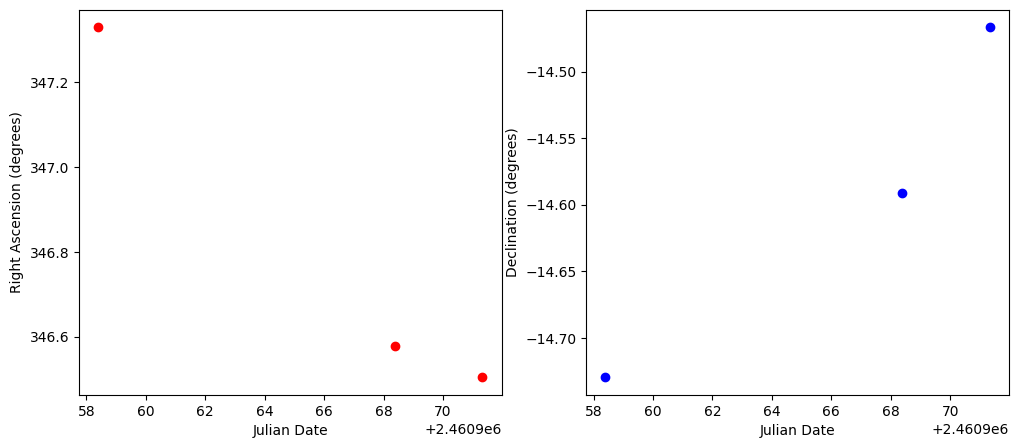

In [ ]:
# Now we have the times, RA, and Dec from across three different nights
# We can use these to fit the orbital parameters of the asteroid 

# Plot the observed RA and Dec separately over time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(times, ra_list, color='red', label='Observed RA')
axes[0].set_ylabel('Right Ascension (degrees)')
axes[0].set_xlabel('Julian Date')

axes[1].scatter(times, dec_list, color='blue', label='Observed Dec')
axes[1].set_ylabel('Declination (degrees)')
axes[1].set_xlabel('Julian Date')



plt.show()



# Now, solve for the orbital elements

In [4]:
import poliastro
import orbitdeterminator
from orbitdeterminator.kep_determination import gauss_method as gm
from astropy.coordinates import EarthLocation, solar_system_ephemeris, get_body_barycentric

c:\Users\Matylda\anaconda3\envs\orbit\lib\site-packages\blessed\terminal.py:222: UserWarning: Failed to setupterm(kind='xterm-color'): Could not find terminal xterm-color
  warnings.warn(msg)


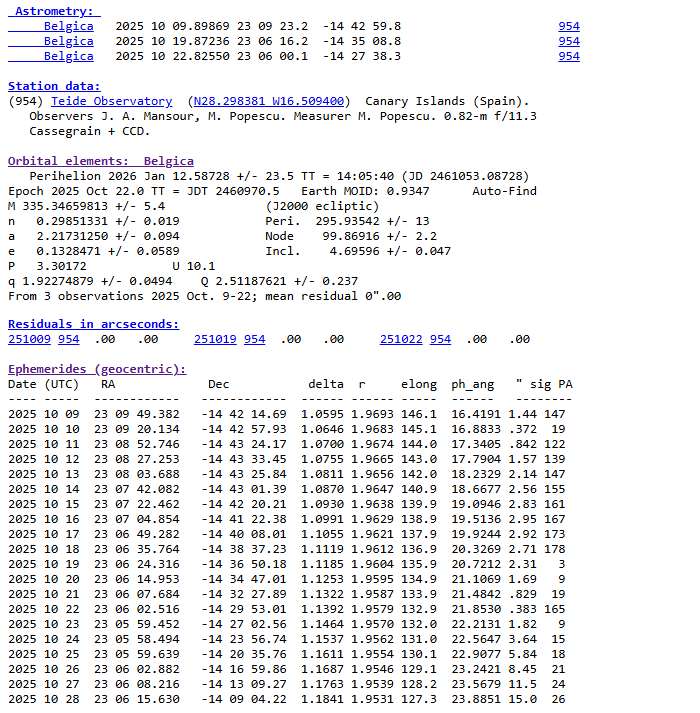